In [1]:
import sys
import os
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import scipy as sp
import seaborn as sns

sys.path.append(os.path.abspath('..'))

from src.pricer import OptionPricer
from src.financial_data import FinancialData, FinancialTools
from src.delta_hedging_simulator import DeltaHedgingSimulator, VectorizedDeltaHedgingSimulator

sns.set_theme(style="whitegrid", font="sans-serif")
sns.despine(top=True, right=True)

<Figure size 640x480 with 0 Axes>

# Replicating Black-Scholes: Discrete Delta Hedging under Market Frictions

## Option pricing

In this section, we evaluate two different option pricing methods : 
* The Cox-Ross-Rubinstein binomial tree
* The Black-Scholes-Merton (BSM) model 

Both have advantages. The binomial method is quite intuitive and allows the pricing of options that can be exerciced before maturity (such as american options), while the BSM model offers a convenient closed form equation to this pricing problem. 

The binomial method, based on discrete time increments $\Delta_t$, is expected to converge towards the continuous time BSM model in the limit where $\Delta_t \rightarrow 0$.

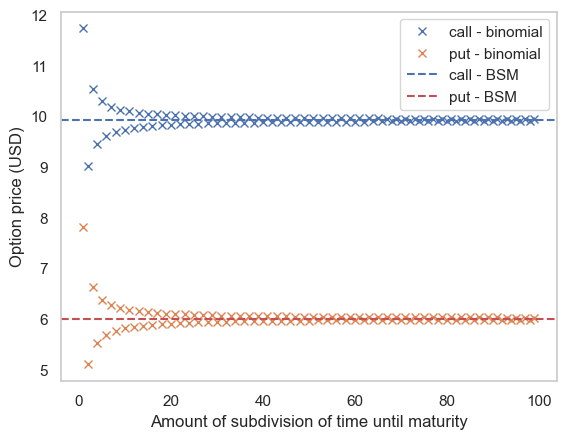

In [2]:
S0 = 100    # initial stock price
K = 100     # strike price
T = 1       # maturity (years)
r = 4/100   # risk free rate
sigma = 0.2 # volatility

amount_subdivisions = range(1,100)
call_prices = np.zeros(len(amount_subdivisions))
put_prices = np.zeros(len(amount_subdivisions))

for k in range(len(amount_subdivisions)):
    N = amount_subdivisions[k]
    pricer = OptionPricer(S0,K,r,sigma,T,"call","binomial", N)
    call_prices[k] = pricer.price()
    pricer = OptionPricer(S0,K,r,sigma,T,"put","binomial", N)
    put_prices[k] = pricer.price()

plt.figure()
plt.plot(amount_subdivisions,call_prices, 'x', label = "call - binomial")
plt.plot(amount_subdivisions,put_prices, 'x', label = "put - binomial")
pricer = OptionPricer(S0,K,r,sigma,T,"call","bsm")
plt.axhline(y=pricer.price(), color='b', linestyle='--', label = "call - BSM")
pricer = OptionPricer(S0,K,r,sigma,T,"put","bsm")
plt.axhline(y=pricer.price(), color='r', linestyle='--', label = "put - BSM")
plt.xlabel("Amount of subdivision of time until maturity")
plt.ylabel("Option price (USD)")
plt.legend()
plt.grid()

The convergence is indeed verified : a larger amount of subdivision (and so smaller time increments) converge towards the expected values obtained with the closed form BSM formulas, for both calls and puts. 

Another interesting visualisation lies in juxtaposing the option payoff at maturity(time $t = T$) and the option value at time $t=0$. 

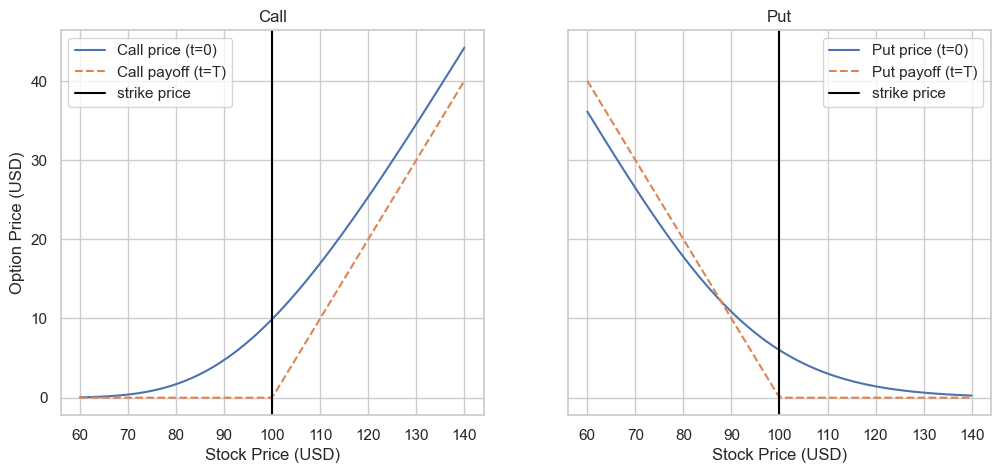

In [3]:
stock_prices = np.linspace(60,140,100)

pricer = OptionPricer(stock_prices,K,r,sigma,T,"call","bsm")
call_prices = pricer.price()
pricer = OptionPricer(stock_prices,K,r,sigma,T,"put","bsm")
put_prices =  pricer.price()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

# Call
ax1.plot(stock_prices, call_prices, label="Call price (t=0)")
ax1.plot(stock_prices, np.maximum(stock_prices - K, 0), "--", label="Call payoff (t=T)")
ax1.set_xlabel("Stock Price (USD)")
ax1.set_ylabel("Option Price (USD)")
ax1.set_title("Call")
ax1.axvline(100,color = "black", label = "strike price")
ax1.legend()
ax1.grid(True)

# Put
ax2.plot(stock_prices, put_prices, label="Put price (t=0)")
ax2.plot(stock_prices, np.maximum(K - stock_prices, 0), "--", label="Put payoff (t=T)")
ax2.set_xlabel("Stock Price (USD)")
ax2.set_title("Put")
ax2.axvline(100,color = "black", label = "strike price")
ax2.legend()
ax2.grid(True)

Interestingly, we can see that when the option is very in the money, the slope of the option price matches that of the payoff at maturity. This is because the odds of exercicing the options are high in this case, meaning that owning this option is essentially the same as owning the underlying asset. 

There is a difference in put and call there, owning an in the money call option is worth more than its intrinsic payoff ($C > S - K$) since it is not yet paid, and the money used to pay it at maturity can be used to earn risk-free interest. For puts it's the opposite, the value of the option is worth less than the intrinsic payoff ($P < K - S$), and we will get cash from selling the underlying asset via the option but only at maturity, meaning that we miss out on those interests.

## Delta-hedging

We now place ourselves in the shoes of a market maker. When shorting a call option, there is an operation that can be done concurently to minimize associated risks. It is known as delta-hedging and consists in buying $\Delta$ units of the underlying assets in order to offset the potential losses associated with selling this option.

This quantity $\Delta$ is derived directly from the BSM partial differential equation as the first-order partial derivative of the option price $V$ with respect to the underlying current price $S$:

$$\Delta_t = \frac{\partial V}{\partial S}$$

For a European Call option in the BSM framework, this derivative yields a closed-form expression bounded in $[0, 1]$.

Under ideal BSM assumptions (continuous rebalancing, zero transaction costs, and constant volatility), having a portfolio composed of $\Delta_t$ shares and a money-market cash account $B_t$ guarantees an identical payoff to the option, perfectly balancing its risks.

We verify this strategy in the ideal case, on simulated data (geometric brownian motion), as follows : 

c:\Users\Guill\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


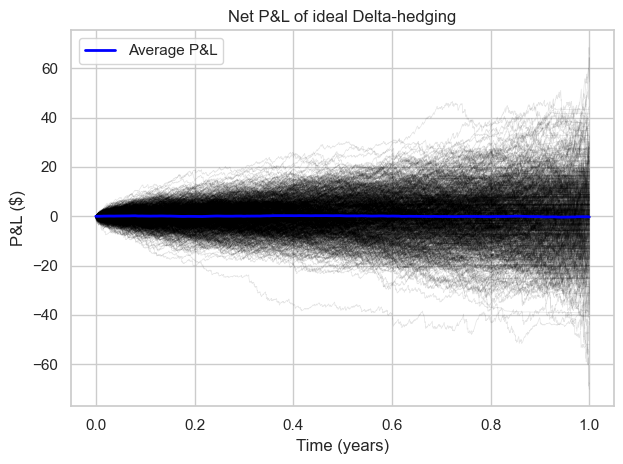

In [4]:

S0 = 100.0      # initial stock prize
K = 100.0       # strike prize
T = 1.0         # time to maturity (in year)
r = 0.03        # riskless rate
sigma_real = 0.20   # Actual volatility of underlying
sigma_imp = 0.20    # implicit volatility (for pricing and delta)
N = 2520        # Amount of time steps : 1 year = 252 trading days
n_options = 100 # Amount of options sold
M = 1000        # Amount of simulations


financial_data = FinancialData(data_type="Simulated_vectorised")
prices = financial_data.get_data(S0=S0, mu=r, sigma=sigma_real, T=T, N=N, M= M)

kp= 0.0 # proportional fees (set to 0 for ideal case)
kf= 0.0 # fixed fees (set to 0 for ideal case)


plt.figure()
delta_hedging_simulator = VectorizedDeltaHedgingSimulator(prices, K, T, r, sigma_imp, kp=kp, kf=kf, n_options=n_options)
df_results = delta_hedging_simulator.simulation()
plt.plot(df_results["time"], df_results["portfolio_value"], alpha = 0.1, lw =0.5, label = "_nolegend_", color = "black")
plt.plot(df_results["time"], np.mean(df_results["portfolio_value"],axis = 1),linestyle = "-", alpha = 1, lw = 2, color = "blue", label = "Average P&L")
plt.title("Net P&L of ideal Delta-hedging")
plt.xlabel("Time (years)")
plt.ylabel("P&L ($)")
plt.legend()
plt.tight_layout()
plt.show()

All trajectories remain relatively close to a net P&L of zero. . The "expected trajectory", displayed in blue as the mean of all the individual paths, is also exceptionaly close to zero. 

Increasing the number of time steps $N$ will further improve the hedging quality, bringing the simulation closer to the continuous case assumed in the BSM model. This raises a question regarding how often the portfolio sould be readjusted in order to maintain a good enough hedge.
In the case in which we have no fee, this question is somewhat trivial and we should always aim for the highest possible rebalancing frequency. 

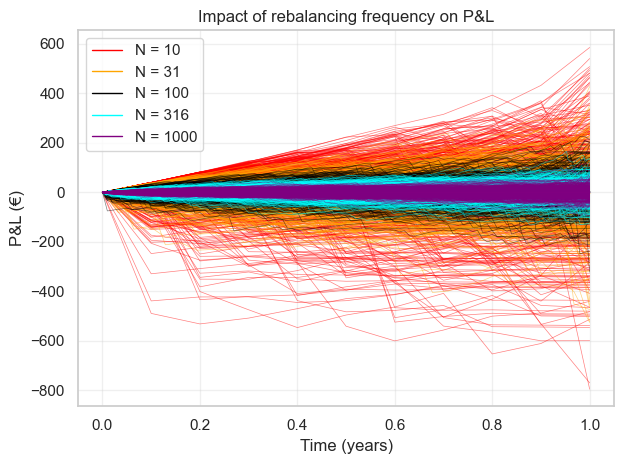

In [5]:
colors = ["red","orange","black","cyan","purple"]
n_vals = np.logspace(1,3,5) # Different rebalancing frequencies

plt.figure()
for k in range(len(n_vals)):
    N = int(n_vals[k])
    color = colors[k]
    prices = financial_data.get_data(S0=S0, mu=r, sigma=sigma_real, T=T, N=N, M= 500)
    delta_hedging_simulator = VectorizedDeltaHedgingSimulator(prices, K, T, r, sigma_imp, kp=kp, kf=kf, n_options=n_options)    
    df_results = delta_hedging_simulator.simulation()
    plt.plot(df_results["time"], df_results["portfolio_value"], alpha = 0.5, lw =0.5, color = color, label = "_nolegend_")
    plt.plot(df_results["time"], np.mean(df_results["portfolio_value"],axis=1), label=f"N = {N}", alpha = 1, lw =1, color = color)#, marker = ".")

plt.title("Impact of rebalancing frequency on P&L")
plt.xlabel("Time (years)")
plt.ylabel("P&L (€)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

This graph shows the importance of the rebalancing frequency : more frequent adaptation of the portfolio leads to less extreme net P&L values and thus mitigates overall risk during the hedging operation.

## Delta-hedging on actual financial data

We now witnessed the principle of delta-hedging on synthetic signals (geometric brownian motions), let's now look at what would happen if we tried the same thing on the actual market. To that end, we backtest this delta-hedging strategy on a synthetic European option written on the S&P 500 index. One curcial question is : how do we chose the value of volatility used by the black Scholes model ? Using the value of the realized volatility is not very sound conceptually, since it requires knowing the future in some form. Let's examine how this choice impacts the final hedging P&L (for now not adding any transaction fee for a fair comparison with the previous graphs):

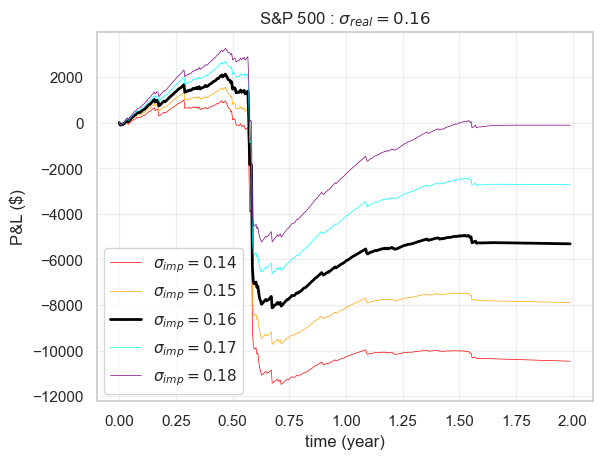

In [6]:
colors = ["red","orange","black","cyan","purple"]

yh_data = FinancialData(data_type="Real")
fin_tools = FinancialTools()
prices_real = yh_data.get_data(ticker="^GSPC", period="2y")

N = len(prices_real) - 1   # amount of observations (N+1 prices)
T = N / 252.0               # maturity in years (assuming 252 trading days per year)
r = 0.03                    # assumed riskless rate 

# Estimate the realized volatility from the historical data
returns_real = fin_tools.daily_returns(prices_real)
sigma_realized = fin_tools.daily_volatility(returns_real) * np.sqrt(252) # annualized volatility

# Sold call option 
S0 = prices_real[0]         # initial stock price
K = S0                      # strike price (ATM)
n_options = 100             # amount of options sold
kp = 0                  # Proportional fees (fixed at zero for now)
kf = 0                  # fixed fees (fixed at zero for now)

# Backtest Delta Hedging with different implied volatilities
imp_vols = np.linspace(sigma_realized-0.02, sigma_realized+0.02, 5)
plt.figure()
for k in range(len(imp_vols)):
    sigma_imp = imp_vols[k]
    sim_real = DeltaHedgingSimulator(prices=prices_real, K=K, T=T, r=r, sigma_imp=sigma_imp, kp=kp, kf=kf, n_options=n_options)
    df_real = sim_real.simulation()
    plt.plot(df_real.index,df_real["portfolio_value"], lw=0.5 if abs(imp_vols[k] - sigma_realized) > 1e-6  else 2, color = colors[k], label = f"$\\sigma_{{imp}} = {sigma_imp:.2f}$")
plt.legend()
plt.xlabel("time (year)")
plt.ylabel("P&L ($)")
plt.title(f"S&P 500 : $\sigma_{{real}} = {sigma_realized:.2f}$")
plt.grid(True, alpha=0.3)
plt.show()

Quite surprisingly, this doesn't look at all like the trajectories from geometric brownian motions obtained before. This can be explains by several reasons:
- The BSM model assumes fixed volatility, while there is no reason for the volatility to be constant in practice.
- Assumption of normal increments while actual markets exhibit "fat tails" : rare events (like crashes) that occur much more frequently than expected
- Jumps : the market closes at night and opens the next morning. During this time, you cannot track the price of the underlying and might exhibit jumps

Let's examine the path of S&P 500 prices during the option duration:

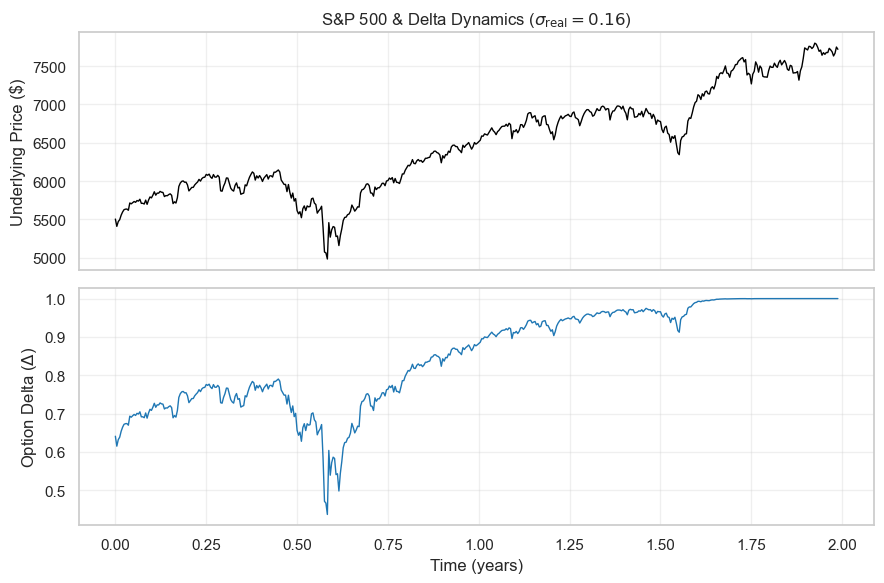

In [7]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(9, 6), sharex=True)

ax1.plot(df_real.index, df_real["price"], lw=1, color="black")
ax1.set_ylabel("Underlying Price ($)")
ax1.set_title(f"S&P 500 & Delta Dynamics ($\sigma_{{\\text{{real}}}} = {sigma_realized:.2f}$)")
ax1.grid(True, alpha=0.3)

ax2.plot(df_real.index, df_real["delta"], lw=1, color="tab:blue")
ax2.set_xlabel("Time (years)")
ax2.set_ylabel("Option Delta ($\Delta$)")
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

We clearly see a crash a little after 6 months in, that considerably impacted the P&L of our hedging simulation. This has several concurrent causes: 
- As the market crashed, the delta changed at a rapid pace and the discrete readjustment of the portfolio could not follow which led to accumulating losses.
- The volatility clearly changes in time, causing a mismatch between the volatility used for BSM model and the actual realized volatility.

## Sensitivity analysis

It becomes evident that some parameters are crucial for ensuring risk mitigation by hedging.

### Impact of readjustment frequency

Something hasn't been considered as of yet, when readjusting a portfolio, one must pay transaction fees. They exist in two kinds : fixed fees (can be very limited for market makers) and proportional fees.

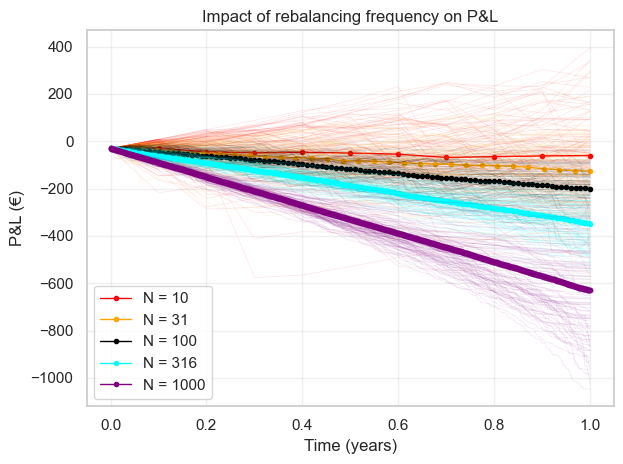

In [8]:
S0 = 100.0      # initial stock prize
K = 100.0       # strike prize
T = 1.0         # time to maturity (in year)
r = 0.03        # riskless rate
sigma_real = 0.20   # Actual volatility of underlying
sigma_imp = 0.20    # implicit volatility (for pricing and delta)
N = 2520        # Amount of time steps : 1 year = 252 trading days
n_options = 100 # Amount of options sold
M = 100        # Amount of simulations
kp= 0.005 # proportional fees 
kf= 0.1 # fixed fees

financial_data = FinancialData(data_type="Simulated_vectorised")
colors = ["red","orange","black","cyan","purple"]

n_vals = np.logspace(1,3,5) # Different rebalancing frequencies

plt.figure()
for k in range(len(n_vals)):
    N = int(n_vals[k])
    color = colors[k]
    prices = financial_data.get_data(S0=S0, mu=r, sigma=sigma_real, T=T, N=N, M= M)
    delta_hedging_simulator = VectorizedDeltaHedgingSimulator(prices, K, T, r, sigma_imp, kp=kp, kf=kf, n_options=n_options)    
    df_results = delta_hedging_simulator.simulation()
    plt.plot(df_results["time"], df_results["portfolio_value"], alpha = 0.1, lw =0.5, color = color, label = "_nolegend_")
    plt.plot(df_results["time"], np.mean(df_results["portfolio_value"],axis=1), label=f"N = {N}", alpha = 1, lw =1, color = color, marker = ".")

plt.title("Impact of rebalancing frequency on P&L")
plt.xlabel("Time (years)")
plt.ylabel("P&L (€)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Evidently, in presence of these fees, readjusting a portfolio comes with a cost and should not be done as often as possible, as this would cause a sharp decrease in P&L.

There is however a tradeoff, since the hedging quality and risk mitigation is increased with higher readjustment frequencies : 

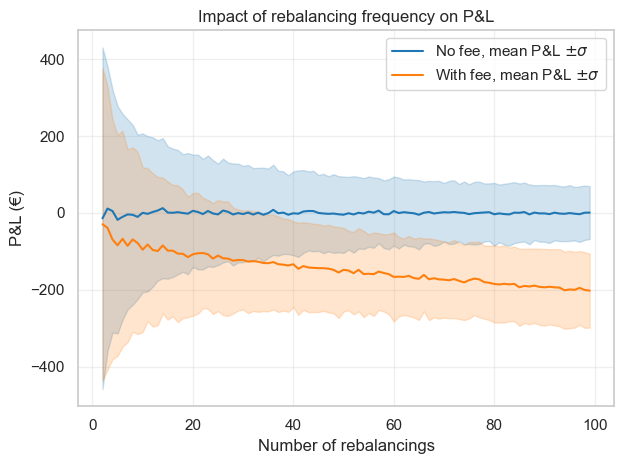

In [9]:
S0 = 100.0      # initial stock prize
K = 100.0       # strike prize
T = 1.0         # time to maturity (in year)
r = 0.03        # riskless rate
sigma_real = 0.20   # Actual volatility of underlying
sigma_imp = 0.20    # implicit volatility (for pricing and delta)
n_options = 100 # Amount of options sold
M = 1000        # Amount of simulations

financial_data = FinancialData(data_type="Simulated_vectorised")

n_vals = np.arange(2,100) # Different rebalancing frequencies

mean_pnl = np.zeros(len(n_vals))
std_pnl = np.zeros(len(n_vals))
mean_pnl_no_fee = np.zeros(len(n_vals))
std_pnl_no_fee = np.zeros(len(n_vals))

kp= 0   # proportional fees 
kf= 0   # fixed fees
for k in range(len(n_vals)):
    N = int(n_vals[k])
    prices = financial_data.get_data(S0=S0, mu=r, sigma=sigma_real, T=T, N=N, M= M)
    delta_hedging_simulator = VectorizedDeltaHedgingSimulator(prices, K, T, r, sigma_imp, kp=kp, kf=kf, n_options=n_options)    
    df_results = delta_hedging_simulator.simulation()
    mean_pnl_no_fee[k] = np.mean(df_results["portfolio_value"][-1,:])
    std_pnl_no_fee[k] = np.std(df_results["portfolio_value"][-1,:])

kp= 0.005   # proportional fees 
kf= 0.1     # fixed fees
for k in range(len(n_vals)):
    N = int(n_vals[k])
    prices = financial_data.get_data(S0=S0, mu=r, sigma=sigma_real, T=T, N=N, M= M)
    delta_hedging_simulator = VectorizedDeltaHedgingSimulator(prices, K, T, r, sigma_imp, kp=kp, kf=kf, n_options=n_options)    
    df_results = delta_hedging_simulator.simulation()
    mean_pnl[k] = np.mean(df_results["portfolio_value"][-1,:])
    std_pnl[k] = np.std(df_results["portfolio_value"][-1,:])

plt.figure()
plt.plot(n_vals,mean_pnl_no_fee, label="No fee, mean P&L $\pm \sigma$",color="tab:blue")
plt.fill_between(n_vals, mean_pnl_no_fee - std_pnl_no_fee, mean_pnl_no_fee + std_pnl_no_fee, color="tab:blue", alpha=0.2, label="_no_label_")
plt.plot(n_vals,mean_pnl, label="With fee, mean P&L $\pm \sigma$",color="tab:orange")
plt.fill_between(n_vals, mean_pnl - std_pnl, mean_pnl + std_pnl, color="tab:orange", alpha=0.2, label="_no_label_")

plt.title("Impact of rebalancing frequency on P&L")
plt.xlabel("Number of rebalancings")
plt.ylabel("P&L (€)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.legend()
plt.show()


### Impact of volatility misestimation

Another crucial parameter is volatility. It is notoriously hard to estimate, and should not be considered as a static value in practice, which is one of the flaws of the BSM model.

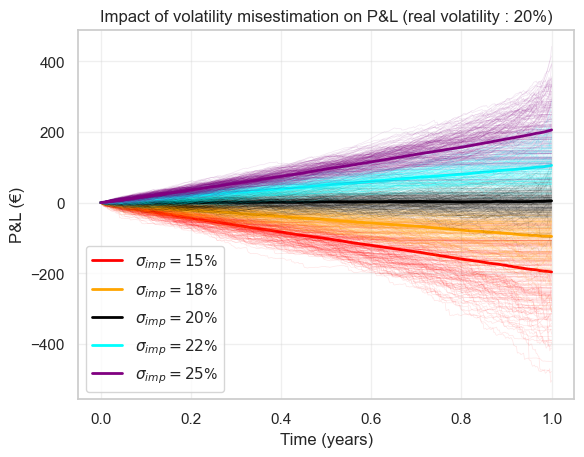

In [10]:
N = 500
M = 200
financial_data = FinancialData(data_type="Simulated_vectorised")
prices = financial_data.get_data(S0=S0, mu=r, sigma=sigma_real, T=T, N=N, M= M)

kp= 0.0 # proportional fees (set to 0 to see the impact of misestimating volatility only)
kf= 0.0 # fixed fees (set to 0 to see the impact of misestimating volatility only)
sigma_imp_values = np.linspace(0.15,0.25,5)  # Underestimated, correct, overestimated

colors = ["red","orange","black","cyan","purple"]

plt.figure()
for k in range(len(sigma_imp_values)):
    sigma_imp = sigma_imp_values[k]
    color = colors[k]
    delta_hedging_simulator = VectorizedDeltaHedgingSimulator(prices, K, T, r, sigma_imp, kp=kp, kf=kf, n_options=n_options)
    df_results = delta_hedging_simulator.simulation()
    plt.plot(df_results["time"], df_results["portfolio_value"], alpha = 0.1, lw =0.5, color = color, label = "_nolegend_")
    plt.plot(df_results["time"], np.mean(df_results["portfolio_value"],axis = 1), label=f"$\sigma_{{imp}} = {sigma_imp*100:.0f}$%", alpha = 1, lw = 2, color = color)
        
plt.title("Impact of volatility misestimation on P&L (real volatility : 20%)")
plt.xlabel("Time (years)")
plt.ylabel("P&L (€)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

We see that the expected behavior is met only for correctly estimated volatility. When it is underestimated, the option is sold too cheap and the rebalancing costs (buying high and selling low to remain covered) will reduce the P&L. Conversely, when the volatility is overestimated, the option is sold too expensive and the rebalancing costs will be lower than expected due to the underlying asset's price being more steady than expected.



#### Conclusion

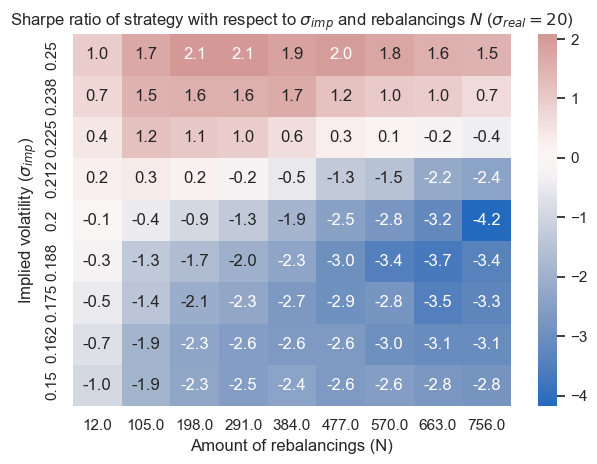

In [11]:
sigma_imps = np.linspace(0.15, 0.25, 9)  # From 15% to 25% with a step of 1%
N_vals = np.linspace(12,252*3,9)

# Paramètres
S0 = 100.0
K = 100.0
T = 1.0
r = 0.03
sigma_real = 0.20
n_options = 100
kp = 0.0005
kf = 0.1
n_sims = 200 # Number of Monte-Carlo simulations per cell


data_sim = FinancialData(data_type="Simulated_vectorised")

summary_data = []

sharpe_matrix = np.zeros((len(sigma_imps), len(N_vals)))

for i in range(len(sigma_imps)):
    for j in range(len(N_vals)):
        sigma_imp = sigma_imps[i]
        N_val = int(N_vals[j])
        
        prices_sim = data_sim.get_data(S0=S0, mu=r, sigma=sigma_real, T=T, N=N_val, M=n_sims)
        sim = VectorizedDeltaHedgingSimulator(prices_sim, K, T, r, sigma_imp=sigma_imp, kp=kp, kf=kf, n_options=n_options)
        res = sim.simulation()

        terminal_pnl = res["portfolio_value"][-1, :]
        mean_pnl = np.mean(terminal_pnl)
        std_pnl = np.std(terminal_pnl)

        # Hedge Sharpe Ratio
        sharpe_matrix[i, j] = mean_pnl / (std_pnl + 1e-8) # 1e-8 in case of null std
        
# Plot
plt.figure()
sns.heatmap(
    sharpe_matrix[::-1], 
    annot=True, 
    fmt=".1f", 
    cmap="vlag", 
    center=0,
    xticklabels=N_vals,
    yticklabels=np.round(sigma_imps[::-1], 3)
)
plt.xlabel("Amount of rebalancings (N)")
plt.ylabel(r"Implied volatility ($\sigma_{imp}$)")
plt.title(r"Sharpe ratio of strategy with respect to $\sigma_{imp}$ and rebalancings $N$ ($\sigma_{real} = 20$)")
plt.tight_layout()
plt.show()


Here, we computed the sharpe ratio of the hedging strategy, which precisely captures the tradeoff between average P&L and standard deviation of the P&L. 

We can see that in the presence of transaction fees, it is generally detrimental for the P&L of a delta-hedging strategy to underestimate the volatility and increase the amount of rebalancing. However, we can see that the amount of rebalancing should be chosen to maximize the sharpe ratio of the strategy. Alternatively, the implied volatility used to price the option can be adjusted (increased) to maintain a neutral or positive P&L depending on the objective, even in the presence of transaction fees.

## Future work

It would be interesting to replace the naive "we reajust the portfolio at fixed times" approach with an adaptative strategy, such as a treshold strategy (we adjust when $|\Delta_{t} - \Delta_{t-1}| > x $, with x a parameter that would need to be tuned for best results).
One other area of interest lies in volatility estimation, it seems clear to me that the realized volatility is not a good enough metric for efficient delta-hedging, and some state estimation methods (such as bayesian filtering or smoothing) might be able to track the volatility during the hedging operation, allowing for more precise covering.
